<a href="https://colab.research.google.com/github/SakshiWadgaokar/HPC_DL/blob/main/imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load IMDB Dataset
from tensorflow.keras.datasets import imdb


In [3]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print("Training Samples:", len(train_data))
print("Testing Samples:", len(test_data))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: 25000
Testing Samples: 25000


In [4]:
# Decode Review Example
word_index = imdb.get_word_index()

reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()]
)

decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]]
)

print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

In [5]:
# Convert Reviews into Vectors
def vectorize_sequences(sequences, dimension=10000):

    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1

    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [6]:
# Convert Labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')


In [7]:
# Build Model
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()

model.add(layers.Dense(
    16,
    activation='relu',
    input_shape=(10000,)
))

model.add(layers.Dense(
    16,
    activation='relu'
))

model.add(layers.Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile Model
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    loss=losses.binary_crossentropy,
    metrics=['accuracy']
)

In [9]:
# Validation Data
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


In [10]:
# Train Model
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7707 - loss: 0.5594 - val_accuracy: 0.8530 - val_loss: 0.4380
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8844 - loss: 0.3592 - val_accuracy: 0.8772 - val_loss: 0.3316
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9092 - loss: 0.2663 - val_accuracy: 0.8839 - val_loss: 0.2947
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9300 - loss: 0.2121 - val_accuracy: 0.8750 - val_loss: 0.3065
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9403 - loss: 0.1795 - val_accuracy: 0.8882 - val_loss: 0.2758
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9503 - loss: 0.1521 - val_accuracy: 0.8846 - val_loss: 0.2870
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9579 - loss: 0.1321 - val_accuracy: 0.8801 - val_loss: 0.3132
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9650 - loss: 0.1139 - val_accuracy: 0.8836 - v

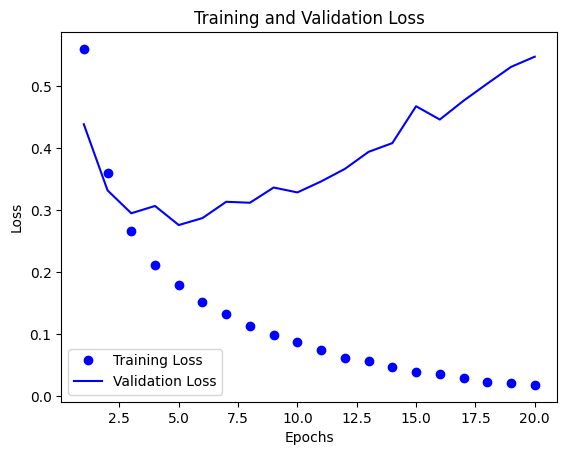

In [11]:
# Training History
history_dict = history.history

# Plot Loss Graph
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(
    epochs,
    loss_values,
    'bo',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss_values,
    'b',
    label='Validation Loss'
)

plt.title('Training and Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.show()


Text(0, 0.5, 'Accuracy')

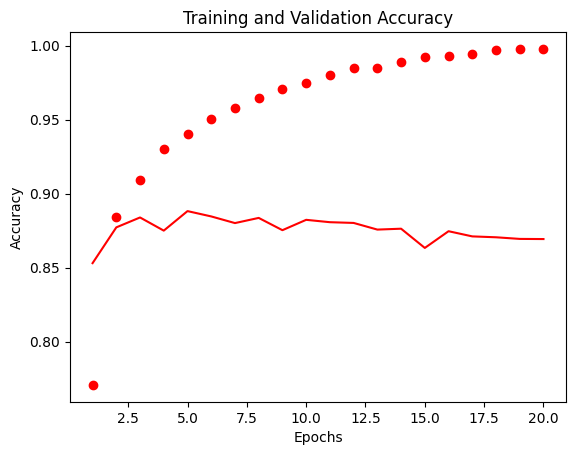

In [12]:
# Plot Accuracy Graph
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(
    epochs,
    acc_values,
    'ro',
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_acc_values,
    'r',
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')


/tmp/ipykernel_4357/440080967.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


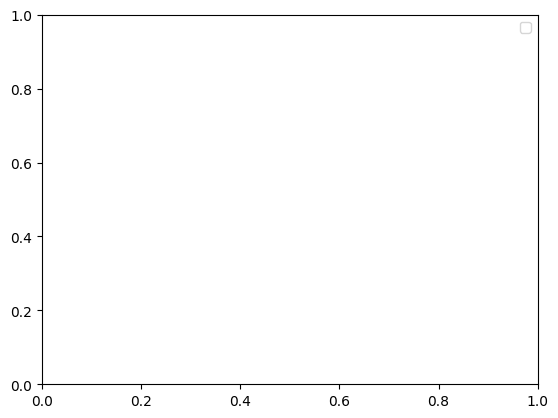

In [13]:
plt.legend()

plt.show()


In [14]:
# Train Again for Final Model
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=3,
    batch_size=512,
    validation_data=(x_val, y_val)
)

# Predictions
result = model.predict(x_test)

print(result)

# Convert Probabilities into 0 or 1
y_pred = np.zeros(len(result))

for i, score in enumerate(result):

    y_pred[i] = 1 if score > 0.5 else 0

# Calculate Error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_pred, y_test)

print("Mean Absolute Error:", mae)

Epoch 1/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9989 - loss: 0.0142 - val_accuracy: 0.8689 - val_loss: 0.5731
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9995 - loss: 0.0120 - val_accuracy: 0.8659 - val_loss: 0.6095
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9973 - loss: 0.0136 - val_accuracy: 0.8678 - val_loss: 0.6189
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1.1727764e-02]
 [9.9999899e-01]
 [9.2746103e-01]
 ...
 [3.8028098e-04]
 [1.3298872e-02]
 [9.7336447e-01]]
Mean Absolute Error: 0.14104
